# PyGAD Genetic Algorithm for the Capacitated Vehicle Routing Problem

This notebook implements a **purely classical Genetic Algorithm** approach to solving the **Capacitated Vehicle Routing Problem (CVRP)** using the PyGAD library.

## Problem Overview
The CVRP is a classic combinatorial optimization problem where:
- Multiple vehicles must deliver goods from a central depot to customer locations
- Each customer has a specific demand
- All vehicles have identical capacity constraints
- The goal is to minimize total travel distance while satisfying all constraints

## Solution Approach
We employ a **genetic algorithm** that:
1. Represents solutions as permutations of customer IDs (order of visits)
2. Uses **ordered crossover** to inherit tour structure from parents
3. Applies **swap mutation** for exploration
4. Decodes permutations into valid multi-route solutions
5. Penalizes infeasible solutions (capacity violations, too many vehicles)

## Benchmark Results
This notebook processes **all instances** from the dataset, runs multiple GA trials on each, and provides comparative analysis of solution quality and stability.

## ⏱️ Time Complexity Analysis

The time complexity of our PyGAD Genetic Algorithm implementation is:

$$
O(G \cdot P \cdot n)
$$

Where:
- **$G$** = number of generations (iterations)
- **$P$** = population size (chromosomes per generation)
- **$n$** = number of customers

### Key Computational Bottlenecks:
- **Fitness evaluation**: $O(P \cdot n)$ per generation (distance calculations)
- **Genetic operators**: $O(P \cdot n)$ per generation (crossover + mutation)
- **Solution decoding**: $O(n)$ per individual (permutation → routes)

## 1. Dependencies & Setup

We require three key libraries:
- **pygad**: Genetic algorithm framework
- **matplotlib**: Route visualization
- **numpy**: Numerical computations and array operations

Install these packages if they're not already available in your environment.

## How Genetic Algorithms Work

### Overview
A **Genetic Algorithm (GA)** is an evolutionary optimization technique inspired by natural selection and genetics. It maintains a **population of candidate solutions** that evolve over multiple generations through reproduction, mutation, and selection, gradually improving toward optimal or near-optimal solutions.

### Key Concepts

#### 1. **Population & Individuals**
- **Population**: A set of candidate solutions (typically 40-60 solutions at once)
- **Individual**: A single route configuration represented as a **permutation of customer IDs** (e.g., `[3, 7, 1, 5, 2, 4, ...]`)
- Each individual's quality is measured by a **fitness score** (inverse of travel distance)

#### 2. **Solution Encoding for VRP**
```
Raw permutation: [2, 5, 1, 4, 3]  ← Order to visit customers
        ↓
Decoded routes:  [0→2→0], [0→5→1→4→0], [0→3→0]  ← Multi-route solution
        ↓
Constraints checked: capacity per vehicle, max vehicles allowed
```

The permutation is decoded by greedily assigning customers to routes, creating a new route when capacity is exceeded.

#### 3. **The GA Lifecycle** (per generation)

**Step 1: Evaluation**
- Calculate total travel distance for each individual's routes
- Assign fitness scores: `fitness = 1 / (1 + distance)`
- **Penalty system**: Infeasible solutions (violating capacity/vehicle limits) receive heavy penalties

**Step 2: Selection** (Tournament-based)
- Stochastically select the **best solutions** (parents) to reproduce
- Better solutions get more chances to create offspring
- This mimics "survival of the fittest"

**Step 3: Crossover** (Creating offspring)
- Take two parent permutations
- **Ordered Crossover (OX)**: Inherit a segment from parent 1, fill remaining positions with parent 2's order
- Example:
  ```
  Parent 1:  [3, 7, 1, | 5, 2, 4, | 6, 8]
  Parent 2:  [2, 5, 8, | 1, 3, 4, | 7, 6]
  Segment:           ↓↓↓↓↓↓↓↓
  Child:     [3, 7, 1, | 5, 2, 4, | ?]  ← Fill with 6,8 from Parent 2
  Result:    [3, 7, 1, 5, 2, 4, 6, 8]
  ```
- Crossover **preserves tour structure** while mixing genetic material

**Step 4: Mutation** (Introducing variation)
- With probability 20%, swap **two random customer positions** in the permutation
- Example: `[3, 7, 1, 5, 2]` → swap positions 1 and 4 → `[3, 2, 1, 5, 7]`
- Mutation allows escape from local optima and explores new regions

**Step 5: Replacement**
- Combine parents + offspring into a new population
- Keep the **best individuals** from both generations (elitism)
- Iterate to next generation

### Why This Works for VRP

| Component | VRP Benefit |
|-----------|------------|
| **Permutation encoding** | Naturally represents customer visit order |
| **Ordered crossover** | Preserves efficient route segments |
| **Mutation** | Explores alternative visit sequences |
| **Fitness penalty** | Enforces capacity and vehicle constraints |
| **Population diversity** | Avoids getting stuck in poor local optima |

### Algorithm Parameters & Impact

| Parameter | Value | Effect |
|-----------|-------|--------|
| **Population size** | 40 | Larger = slower but more diversity |
| **Generations** | 120 | More iterations allow convergence |
| **Mutation rate** | 20% | Higher = more exploration, lower = faster convergence |
| **Tournament size** | 12 parents | Smaller = higher selection pressure |

### Example Execution Flow

```
Generation 1:
  [Distance: 850, 920, 780, 910, ...]  ← Initial random population
  Best so far: 780
  
Generation 2:
  [Distance: 810, 775, 800, 760, ...]  ← After crossover & mutation
  Best so far: 760
  
Generation 50:
  [Distance: 425, 418, 430, 422, ...]  ← Converged to better solutions
  Best so far: 418
  
Generation 120:
  [Distance: 398, 401, 395, 399, ...]  ← Final near-optimal solution
  Best: 395
```

The algorithm explores the **massive solution space** (millions of possible routes) efficiently by:
- Learning from good solutions via crossover
- Exploring new areas via mutation  
- Progressively improving over 120 generations


## Implementation Details

### Core Functions Explained

#### **Distance Calculation**
- `euclidean_distance()`: Calculates straight-line distance between two customer locations
- `build_distance_matrix()`: Pre-computes distances between all customer pairs for fast lookup

#### **Route Evaluation**  
- `decode_permutation()`: Converts a permutation into multi-route solution by greedily filling vehicles
  - Iterates through customer order, adds to current route if capacity allows
  - Creates new route when customer doesn't fit
- `route_cost()`: Sums distances for one route from depot back to depot
- `total_cost()`: Sums costs across all routes

#### **Evolutionary Operators**
- `ordered_crossover()`: Creates child by preserving parent1's segment, filling gaps with parent2's order
- `crossover_func()`: PyGAD wrapper that applies ordered crossover to population pairs
- `mutation_func()`: Randomly swaps customer positions with 20% probability

#### **Fitness Evaluation**
- `fitness_func()`: Core GA fitness function called per individual
  - Returns penalized fitness if infeasible (capacity exceeded, too many vehicles)
  - Returns `1 / (1 + distance)` for feasible solutions
  - Tracks the best solution ever found

#### **Main Solver Class** (`OfficialPyGADVRP`)
- Initializes distance matrix and customer data
- Runs PyGAD GA with custom crossover/mutation operators
- Returns best solution found after all generations

In [6]:
!pip install pygad matplotlib numpy


In [ ]:
import json
import math
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pygad

# ==================== DISTANCE CALCULATIONS ====================

def euclidean_distance(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    """Calculate straight-line distance between two 2D points"""
    return math.hypot(a[0] - b[0], a[1] - b[1])

def build_distance_matrix(customers: List[Dict[str, Any]]) -> np.ndarray:
    """Pre-compute distances between all customer pairs for fast lookup during GA evaluation"""
    coords = [(float(c["x"]), float(c["y"])) for c in customers]  # Extract (x,y) coordinates
    n = len(coords)
    dist = np.zeros((n, n), dtype=float)  # NxN distance matrix
    for i in range(n):
        for j in range(n):
            dist[i, j] = euclidean_distance(coords[i], coords[j])  # Fill matrix with pairwise distances
    return dist

# ==================== COST EVALUATION ====================

def route_cost(route: List[int], dist: np.ndarray) -> float:
    """Calculate total distance for a single route (depot → customers → depot)"""
    if len(route) < 2:
        return 0.0
    # Sum distances between consecutive nodes in the route
    return float(sum(dist[route[i], route[i + 1]] for i in range(len(route) - 1)))

def total_cost(routes: List[List[int]], dist: np.ndarray) -> float:
    """Calculate total distance across all routes (multi-route solution cost)"""
    return float(sum(route_cost(route, dist) for route in routes))

# ==================== SOLUTION DECODING ====================

def decode_permutation(
    permutation: List[int],
    demands: Dict[int, int],
    capacity: int,
    max_vehicles: int,
) -> Tuple[List[List[int]], bool]:
    """
    Convert a customer visit order (permutation) into multi-route solution.
    Uses greedy approach: assigns customers to routes in order, creating new route when capacity exceeded.
    Returns (routes, feasible) where feasible=True if solution respects all constraints.
    """
    routes: List[List[int]] = []
    current_route: List[int] = [0]  # Start route at depot (node 0)
    current_load = 0

    for customer_id in permutation:
        demand = demands[customer_id]
        # Reject if single customer exceeds vehicle capacity
        if demand > capacity:
            return [], False
        # If customer fits in current route, add it
        if current_load + demand <= capacity:
            current_route.append(customer_id)
            current_load += demand
        # Otherwise, close current route and start new one
        else:
            current_route.append(0)  # Return to depot
            routes.append(current_route)
            current_route = [0, customer_id]  # New route with depot + this customer
            current_load = demand
    
    # Close the last route
    current_route.append(0)
    routes.append(current_route)
    
    # Check if number of routes respects vehicle constraint
    feasible = len(routes) <= max_vehicles
    return routes, feasible

# ==================== GENETIC OPERATORS: CROSSOVER ====================

def ordered_crossover(parent1: np.ndarray, parent2: np.ndarray) -> np.ndarray:
    """
    Ordered Crossover (OX): Preserve tour structure while mixing parental genes.
    
    Process:
    1. Select random segment from parent1 → put in child
    2. Take remaining customers from parent2 (in order) → fill remaining positions
    
    Example:
      Parent1: [3, 7, 1, 5, 2, 4]
      Parent2: [2, 5, 8, 1, 3, 4]
      Segment: [5, 2, 4] (positions 3-5)
      Child:   [3, 7, 1, 5, 2, 4] ← Inherits parent1's segment + parent2's remaining order
    """
    size = len(parent1)
    child = np.full(size, -1, dtype=int)  # Initialize empty child
    
    # Select random segment boundaries
    left, right = sorted(random.sample(range(size), 2))
    # Copy segment from parent1 to child
    child[left:right + 1] = parent1[left:right + 1]
    
    # Get remaining customers from parent2 (preserving parent2's order)
    remaining = [gene for gene in parent2 if gene not in child]
    # Identify empty positions in child
    fill_positions = [i for i in range(size) if child[i] == -1]
    # Fill empty positions with remaining customers
    for pos, gene in zip(fill_positions, remaining):
        child[pos] = gene
    return child

def crossover_func(parents: np.ndarray, offspring_size: Tuple[int, int], ga_instance) -> np.ndarray:
    """PyGAD wrapper: Apply ordered crossover to parent pairs"""
    offspring = []
    for k in range(offspring_size[0]):
        # Pair consecutive parents, wrapping around if needed
        p1 = parents[k % parents.shape[0]].astype(int)
        p2 = parents[(k + 1) % parents.shape[0]].astype(int)
        offspring.append(ordered_crossover(p1, p2))
    return np.array(offspring, dtype=int)

# ==================== GENETIC OPERATORS: MUTATION ====================

def mutation_func(offspring: np.ndarray, ga_instance) -> np.ndarray:
    """
    Swap Mutation: Randomly swap two customer positions in permutation.
    Introduces variation to escape local optima and explore new solutions.
    
    Example (mutation_prob=20%):
      Before: [3, 7, 1, 5, 2] → Swap positions 1 & 4
      After:  [3, 2, 1, 5, 7]
    """
    mutated = offspring.copy()
    for i in range(mutated.shape[0]):
        # Mutate with probability defined in GA settings (default 20%)
        if random.random() < ga_instance.mutation_probability:
            # Select two random positions and swap them
            a, b = random.sample(range(mutated.shape[1]), 2)
            mutated[i, a], mutated[i, b] = mutated[i, b], mutated[i, a]
    return mutated

# ==================== MAIN GENETIC ALGORITHM SOLVER ====================

class OfficialPyGADVRP:
    """Genetic Algorithm solver for Capacitated Vehicle Routing Problem using PyGAD"""
    
    def __init__(
        self,
        instance: Dict[str, Any],
        num_generations: int = 200,
        sol_per_pop: int = 60,
        num_parents_mating: int = 20,
        mutation_probability: float = 0.2,
        seed: int = 42,
    ):
        """Initialize solver with CVRP instance and GA parameters"""
        # Problem instance parameters
        self.instance_id = instance["instance_id"]
        self.Nv = int(instance["Nv"])  # Number of available vehicles
        self.C = int(instance["C"])     # Vehicle capacity
        self.raw_customers = instance["customers"]
        
        # GA parameters
        self.num_generations = int(num_generations)  # How many generations to evolve
        self.sol_per_pop = int(sol_per_pop)          # Solutions per generation
        self.num_parents_mating = int(num_parents_mating)  # How many solutions breed
        self.mutation_probability = float(mutation_probability)  # Chance to mutate
        self.seed = int(seed)  # Reproducibility
        random.seed(self.seed)
        np.random.seed(self.seed)
        
        # Parse customer data
        self.customers = self.raw_customers
        self.depot = None
        self.customer_ids: List[int] = []  # List of customer IDs (1, 2, 3, ...)
        self.demands: Dict[int, int] = {}  # customer_id → demand mapping
        
        for c in self.customers:
            cid = int(c["customer_id"])
            self.demands[cid] = int(c["demand"])  # Store demand for each customer
            if cid == 0:
                self.depot = (float(c["x"]), float(c["y"]))  # Extract depot location
            else:
                self.customer_ids.append(cid)  # Add to customer list
        
        if self.depot is None:
            raise ValueError("Depot (customer_id=0) not found in the instance.")
        
        self.customer_ids.sort()  # Sort for consistency
        
        # Pre-compute distance matrix for fast lookup
        self.dist = build_distance_matrix(self.customers)
        
        # Track best solution found during entire run
        self.best_distance = float("inf")
        self.best_routes: List[List[int]] = []
        self.best_valid = False
        self.last_runtime = 0.0

    def initial_population(self) -> np.ndarray:
        """Generate initial random population of permutations"""
        base = np.array(self.customer_ids, dtype=int)  # [1, 2, 3, ..., N]
        population = []
        for _ in range(self.sol_per_pop):
            candidate = base.copy()
            np.random.shuffle(candidate)  # Randomly shuffle customer order
            population.append(candidate)
        return np.array(population, dtype=int)

    def evaluate(self, solution: np.ndarray) -> Tuple[float, float, bool, List[List[int]]]:
        """Evaluate a solution permutation: decode to routes and calculate fitness"""
        perm = [int(x) for x in solution.tolist()]
        
        # Validate: permutation must contain all customers exactly once
        if sorted(perm) != sorted(self.customer_ids):
            penalty_cost = 1e9
            return 1.0 / (1.0 + penalty_cost), penalty_cost, False, []
        
        # Decode permutation into multi-route solution
        routes, feasible = decode_permutation(perm, self.demands, self.C, self.Nv)
        
        # Calculate total travel distance
        distance = total_cost(routes, self.dist) if routes else 1e9
        
        # If infeasible (too many vehicles or capacity violations), apply heavy penalty
        if not feasible:
            overflow = max(0, len(routes) - self.Nv)  # How many extra vehicles needed?
            penalty_cost = distance + 100000.0 * overflow + 100000.0  # Large penalty
            return 1.0 / (1.0 + penalty_cost), penalty_cost, False, routes
        
        # Feasible solution: fitness is inverse of distance (shorter = higher fitness)
        fitness = 1.0 / (1.0 + distance)
        return fitness, distance, True, routes

    def fitness_func(self, ga_instance, solution, solution_idx):
        """Called by PyGAD for each individual per generation. Tracks best solution."""
        fitness, distance, valid, routes = self.evaluate(solution)
        # Update best if this is valid AND better than previous best
        if valid and distance < self.best_distance:
            self.best_distance = distance
            self.best_routes = [route[:] for route in routes]
            self.best_valid = True
        return fitness

    def solve(self) -> Dict[str, Any]:
        """Run the GA for specified generations and return best solution found"""
        start = time.perf_counter()
        
        # Configure and run PyGAD genetic algorithm
        ga = pygad.GA(
            # Evolution parameters
            num_generations=self.num_generations,        # How many generations to evolve
            num_parents_mating=self.num_parents_mating,  # How many solutions breed per gen
            sol_per_pop=self.sol_per_pop,                # Population size
            # Genetic operators
            crossover_type=crossover_func,               # Use ordered crossover
            mutation_type=mutation_func,                 # Use swap mutation
            mutation_probability=self.mutation_probability,  # 20% chance per solution
            # Fitness and selection
            fitness_func=self.fitness_func,              # Our fitness evaluator
            parent_selection_type="sss",                 # Steady-state selection
            keep_parents=4,                              # Elitism: keep best 4 solutions
            # Problem setup
            num_genes=len(self.customer_ids),            # Number of customers to visit
            gene_type=int,                               # Genes are customer IDs (integers)
            initial_population=self.initial_population(), # Start with random shuffles
            # Configuration
            random_seed=self.seed,
            suppress_warnings=True,
        )
        
        # Execute GA: evolves population through generations
        ga.run()
        
        # Extract best solution from final generation
        best_solution, best_fitness, _ = ga.best_solution()
        _, distance, valid, routes = self.evaluate(best_solution)
        
        runtime = time.perf_counter() - start
        self.last_runtime = runtime
        
        return {
            "instance_id": self.instance_id,
            "distance": distance,
            "runtime": runtime,
            "valid": valid,
            "routes": routes,
            "fitness": best_fitness,
        }

In [ ]:
# ==================== VISUALIZATION & ANALYSIS FUNCTIONS ====================

def plot_routes(routes: List[List[int]], customers: List[Dict[str, Any]], title: str = None) -> None:
    """
    Visualize solution routes on 2D map with each route in a different color.
    - Black 'X': Depot (starting/ending point)
    - Colored lines: Individual routes
    - Numbers: Customer IDs
    """
    # Extract coordinates for all customers
    coords = {int(c["customer_id"]): (float(c["x"]), float(c["y"])) for c in customers}
    
    colors = plt.cm.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot depot
    depot_x, depot_y = coords[0]
    ax.scatter(depot_x, depot_y, marker="X", color="black", s=130, label="Depot")
    
    # Plot each route in a different color
    for route_index, route in enumerate(routes):
        xs = [coords[node][0] for node in route]  # X coordinates for this route
        ys = [coords[node][1] for node in route]  # Y coordinates for this route
        color = colors(route_index % 10)  # Cycle through colors if >10 routes
        
        # Draw line connecting route nodes
        ax.plot(xs, ys, marker="o", color=color, label=f"Route {route_index + 1}")
        
        # Label each node with customer ID
        for node, x, y in zip(route, xs, ys):
            ax.text(x, y, str(node), fontsize=9, ha="right", va="bottom")
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", alpha=0.35)
    if title:
        ax.set_title(title)
    ax.legend(loc="best", fontsize="small", ncol=2)
    plt.show()

def run_trials(
    instance: Dict[str, Any],
    trials: int = 5,
    num_generations: int = 120,
    sol_per_pop: int = 40,
    num_parents_mating: int = 12,
    mutation_probability: float = 0.2,
    base_seed: int = 100,
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """
    Run GA solver multiple times (trials) with different random seeds.
    Useful for assessing solution quality stability and variability.
    Returns: (list of per-trial records, best result overall)
    """
    trial_records: List[Dict[str, Any]] = []
    best_result = None
    
    for trial_idx in range(1, trials + 1):
        # Use different seed for each trial to explore different search paths
        seed = base_seed + trial_idx - 1
        
        # Create and run solver
        solver = OfficialPyGADVRP(
            instance=instance,
            num_generations=num_generations,
            sol_per_pop=sol_per_pop,
            num_parents_mating=num_parents_mating,
            mutation_probability=mutation_probability,
            seed=seed,
        )
        result = solver.solve()
        trial_records.append({
            "trial": trial_idx,
            "seed": seed,
            "distance": float(result["distance"]),
            "runtime": float(result["runtime"]),
            "valid": bool(result["valid"]),
        })
        
        # Track overall best solution across all trials
        if best_result is None or result["distance"] < best_result["distance"]:
            best_result = result
        
        print(f"Trial {trial_idx}/{trials}: distance={result['distance']:.2f}, valid={result['valid']}, runtime={result['runtime']:.2f}s")
    
    return trial_records, best_result

def plot_distance_summary(distances: List[float], title: str = "Trial distances") -> None:
    """
    Create bar chart comparing total distances across multiple trials.
    Shows solution consistency - low variation indicates robust algorithm.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, len(distances) + 1), distances, color="tab:blue")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Distance")
    ax.set_title(title)
    ax.set_xticks(range(1, len(distances) + 1))
    ax.grid(True, linestyle="--", alpha=0.4)
    
    # Label each bar with its value
    for idx, value in enumerate(distances, start=1):
        ax.text(idx, value + max(distances)*0.01, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
    
    plt.show()

## 2. Batch Processing: Solve All Instances

This section loads **ALL CVRP instances** from the dataset and runs the genetic algorithm solver on each one.

For each instance, we:
- Execute multiple independent GA trials (with different random seeds)
- Track the best distance found across all trials
- Visualize the best route discovered
- Collect timing and validity statistics

This comprehensive approach allows us to evaluate **solution quality consistency** and **algorithm robustness** across diverse problem instances.

In [ ]:
# Load all instances from the dataset
instance_path = Path("final_instances.json")
with open(instance_path, "r", encoding="utf-8") as f:
    all_instances = json.load(f)

print(f"Loaded {len(all_instances)} instances from {instance_path}")
print("=" * 70)

# Display instance metadata (problem size, constraints)
for idx, inst in enumerate(all_instances, start=1):
    n_customers = len(inst["customers"]) - 1  # Exclude depot
    print(f"Instance {idx}: {inst['instance_id']:20s} | Customers: {n_customers:3d} | Vehicles: {inst['Nv']:2d} | Capacity: {inst['C']:4d}")

Loaded 6 instances from final_instances.json
Instance 1: 1                    | Customers:   3 | Vehicles:  2 | Capacity:    5
Instance 2: 2                    | Customers:   3 | Vehicles:  2 | Capacity:    2
Instance 3: 3                    | Customers:   6 | Vehicles:  3 | Capacity:    2
Instance 4: 4                    | Customers:  12 | Vehicles:  4 | Capacity:    3
Instance 5: 5                    | Customers:  20 | Vehicles:  5 | Capacity:    4
Instance 6: 6                    | Customers:  25 | Vehicles:  5 | Capacity:    5


## 3. Execute GA Solver on All Instances

Run the genetic algorithm on each instance with multiple trials to capture solution variability.

**Configuration:**
- **Trials per instance**: 5 (enables performance comparison)
- **Generations**: 120 (balance between quality and runtime)
- **Population size**: 40 solutions per generation
- **Parents per mating**: 12 (selection pressure)
- **Mutation rate**: 20% (exploration mechanism)

Results are collected and displayed in a summary table for easy comparison.

In [ ]:
# ==================== BATCH SOLVE ALL INSTANCES ====================
# Process all instances with multiple trials

results_summary = []  # Store aggregate statistics for each instance
all_best_results = []  # Store best result found for each instance

ga_trials = 5
ga_num_generations = 120
ga_sol_per_pop = 40
ga_num_parents_mating = 12
ga_mutation_probability = 0.2
ga_config_label = (
    f"GA | {ga_trials} trials | {ga_num_generations} generations | "
    f"population {ga_sol_per_pop} | {ga_num_parents_mating} parents | 20% mutation"
)

print("\nRunning GA solver on all instances...\n")
print("=" * 70)

for inst_idx, instance in enumerate(all_instances, start=1):
    print(f"\n[Instance {inst_idx}/{len(all_instances)}] {instance['instance_id']}")
    print("-" * 70)
    
    # Run multiple trials with different random seeds to assess robustness
    trial_records, best_result = run_trials(
        instance=instance,
        trials=ga_trials,  # 5 independent GA runs per instance
        num_generations=ga_num_generations,  # Each run evolves for 120 generations
        sol_per_pop=ga_sol_per_pop,  # 40 solutions in population
        num_parents_mating=ga_num_parents_mating,  # 12 solutions reproduce each generation
        mutation_probability=ga_mutation_probability,  # 20% mutation rate
        base_seed=1000 + inst_idx * 100,  # Different seed for each instance
    )
    
    distances = [record["distance"] for record in trial_records]
    runtimes = [record["runtime"] for record in trial_records]
    valid_trials = sum(1 for record in trial_records if record["valid"])
    
    # Calculate statistics across the 5 trials
    min_dist = min(distances)  # Best solution found
    max_dist = max(distances)  # Worst solution found
    avg_dist = sum(distances) / len(distances)  # Average quality
    std_dist = (sum((x - avg_dist)**2 for x in distances) / len(distances)) ** 0.5  # Consistency
    
    # Store results for later comparison
    results_summary.append({
        "instance_id": instance["instance_id"],
        "n_customers": len(instance["customers"]) - 1,
        "vehicles": instance["Nv"],
        "config": ga_config_label,
        "trial_records": trial_records,
        "best": min_dist,
        "worst": max_dist,
        "average": avg_dist,
        "std_dev": std_dist,
        "avg_runtime": sum(runtimes) / len(runtimes),
        "valid": best_result["valid"],
        "valid_trials": valid_trials,
        "routes": len(best_result["routes"]),
        "runtime": best_result["runtime"],
    })
    all_best_results.append(best_result)
    
    # Display trial statistics
    print(f"\nBest:    {min_dist:.2f}")
    print(f"Worst:   {max_dist:.2f}")
    print(f"Average: {avg_dist:.2f} ± {std_dist:.2f}")
    print(f"Valid:   {best_result['valid'] and 'Yes' or 'No'} (routes used: {len(best_result['routes'])}/{instance['Nv']})")

print("\n" + "=" * 70)


Running GA solver on all instances...


[Instance 1/6] 1
----------------------------------------------------------------------
Trial 1/5: distance=21.74, valid=True, runtime=0.07s
Trial 2/5: distance=21.74, valid=True, runtime=0.07s
Trial 3/5: distance=21.74, valid=True, runtime=0.08s
Trial 4/5: distance=21.74, valid=True, runtime=0.07s
Trial 5/5: distance=21.74, valid=True, runtime=0.07s

Best:    21.74
Worst:   21.74
Average: 21.74 ± 0.00
Valid:   Yes (routes used: 1/2)

[Instance 2/6] 2
----------------------------------------------------------------------
Trial 1/5: distance=26.18, valid=True, runtime=0.07s
Trial 2/5: distance=26.18, valid=True, runtime=0.07s
Trial 3/5: distance=26.18, valid=True, runtime=0.08s
Trial 4/5: distance=26.18, valid=True, runtime=0.07s
Trial 5/5: distance=26.18, valid=True, runtime=0.07s

Best:    26.18
Worst:   26.18
Average: 26.18 ± 0.00
Valid:   Yes (routes used: 2/2)

[Instance 3/6] 3
----------------------------------------------------------------

## 4. Results Summary & Analysis

Display comprehensive benchmark results across all instances in an easy-to-read table format.

In [ ]:
# ==================== DISPLAY RESULTS TABLE ====================
# Create formatted table for easy comparison across all instances

print("\n" + "=" * 130)
print(f"{'Instance':<25} {'Customers':>10} {'Vehicles':>8} {'Best':>12} {'Avg':>12} {'Std Dev':>12} {'Valid':>8}")
print("=" * 130)

for result in results_summary:
    valid_str = "✓" if result["valid"] else "✗"  # Check mark for feasible solutions
    print(f"{result['instance_id']:<25} {result['n_customers']:>10d} {result['vehicles']:>8d} "
          f"{result['best']:>12.2f} {result['average']:>12.2f} {result['std_dev']:>12.2f} {valid_str:>8}")

print("=" * 130)

# Calculate and display overall benchmark statistics
all_best_distances = [r["best"] for r in results_summary]
all_avg_distances = [r["average"] for r in results_summary]
valid_count = sum(1 for r in results_summary if r["valid"])

print(f"\nOVERALL STATISTICS:")
print(f"  Total instances solved:        {len(results_summary)}")
print(f"  Feasible solutions:            {valid_count}/{len(results_summary)}")
print(f"  Average best distance:         {sum(all_best_distances) / len(all_best_distances):.2f}")
print(f"  Average across all trials:     {sum(all_avg_distances) / len(all_avg_distances):.2f}")
print(f"  Best solution found:           {min(all_best_distances):.2f} ({results_summary[all_best_distances.index(min(all_best_distances))]['instance_id']})")
print(f"  Worst solution found:          {max(all_best_distances):.2f} ({results_summary[all_best_distances.index(max(all_best_distances))]['instance_id']})")


Instance                   Customers Vehicles         Best          Avg      Std Dev    Valid
1                                  3        2        21.74        21.74         0.00        ✓
2                                  3        2        26.18        26.18         0.00        ✓
3                                  6        3        49.50        49.50         0.00        ✓
4                                 12        4        58.18        58.33         0.12        ✓
5                                 20        5        86.75        89.30         2.49        ✓
6                                 25        5       111.49       117.04         4.50        ✓

OVERALL STATISTICS:
  Total instances solved:        6
  Feasible solutions:            6/6
  Average best distance:         58.98
  Average across all trials:     60.35
  Best solution found:           21.74 (1)
  Worst solution found:          111.49 (6)


## 5. Export Benchmark CSV

Write a benchmark table to `GA_Results/ga_results.csv` using the same general conventions as the QITE and QAOA result files, while omitting quantum-only metadata such as qubits and gate counts.

In [ ]:
# ==================== EXPORT BENCHMARK CSV ====================

import csv

ga_results_path = Path("../ga_results.csv")
fieldnames = [
    "instance",
    "config",
    "trial_1",
    "trial_2",
    "trial_3",
    "trial_4",
    "trial_5",
    "avg_value",
    "best_value",
    "avg_time_s",
    "notes",
]

ga_csv_rows = []

for result in results_summary:
    trial_records = result["trial_records"]
    trial_values = [record["distance"] for record in trial_records]
    trial_count = len(trial_records)
    values_match = max(trial_values) - min(trial_values) < 1e-9

    notes = (
        f"{result['valid_trials']}/{trial_count} trials feasible; "
        + ("all trials matched" if values_match else "trial values varied across seeds")
    )

    row = {
        "instance": result["instance_id"],
        "config": result["config"],
        "avg_value": f"{result['average']:.2f}",
        "best_value": f"{result['best']:.2f}",
        "avg_time_s": f"{result['avg_runtime']:.2f}",
        "notes": notes,
    }

    for idx, value in enumerate(trial_values, start=1):
        row[f"trial_{idx}"] = f"{value:.2f}"

    ga_csv_rows.append(row)

with open(ga_results_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ga_csv_rows)

print(f"Saved GA benchmark table to {ga_results_path.resolve()}")

## 6. Visualize Best Solutions

Display the best route configuration found for each instance. Each color represents a unique delivery route from the depot.

Generating visualizations



C:\Users\toanl\AppData\Local\Temp\ipykernel_58676\3718162953.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")


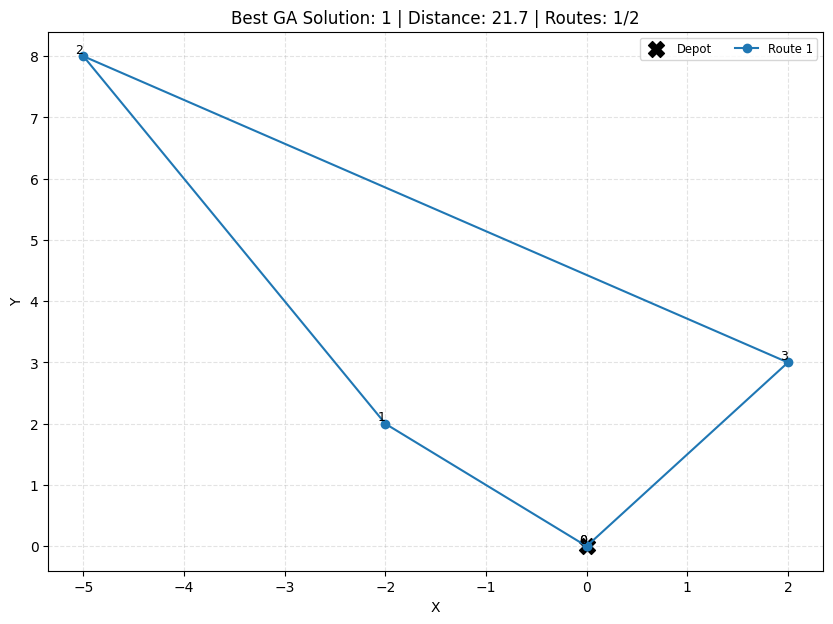

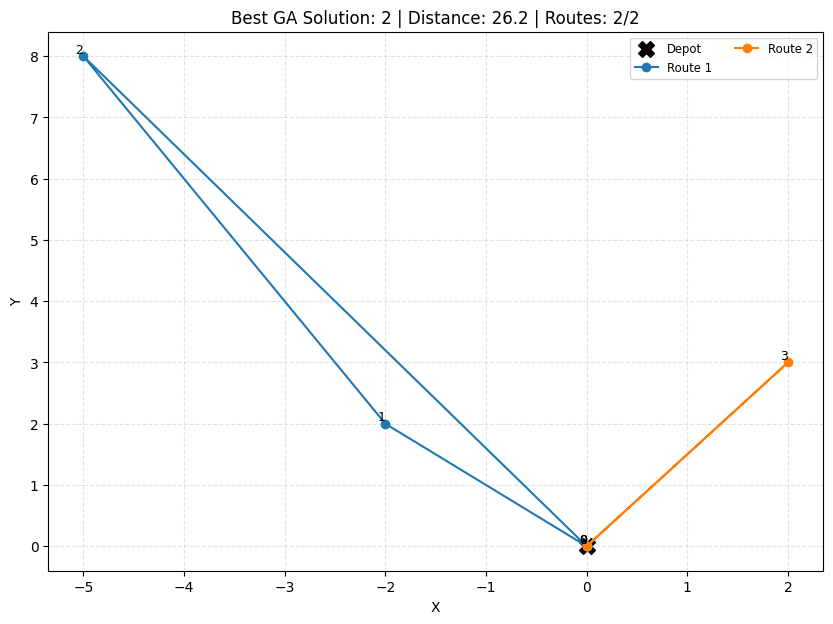

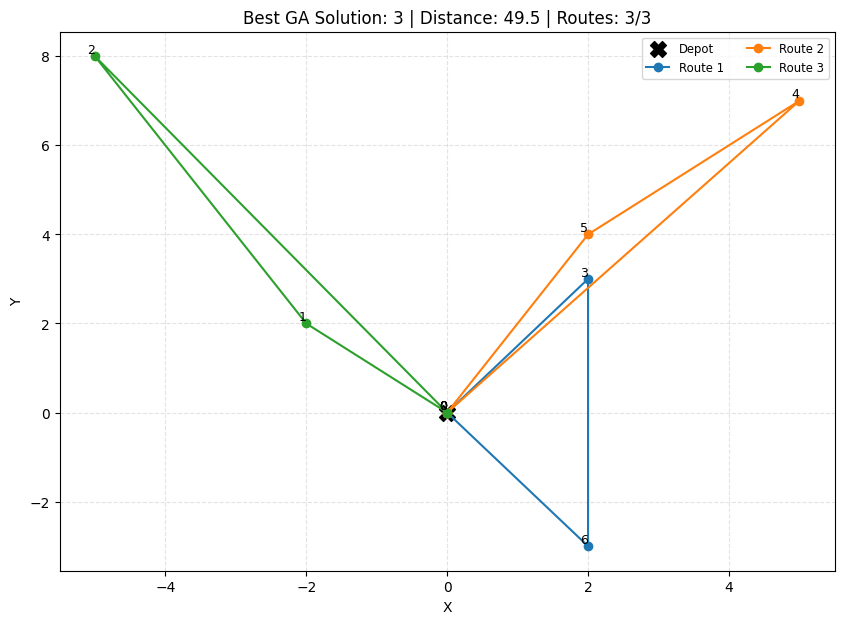

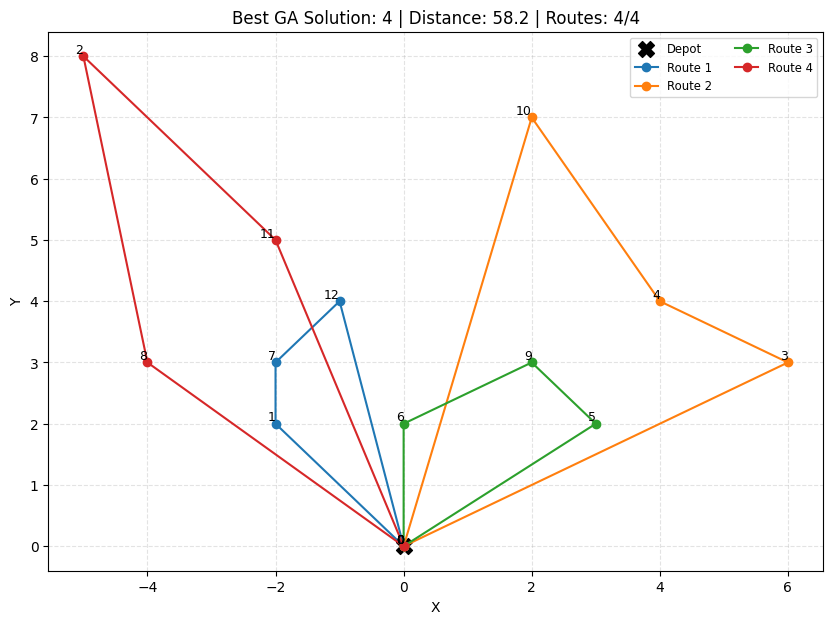

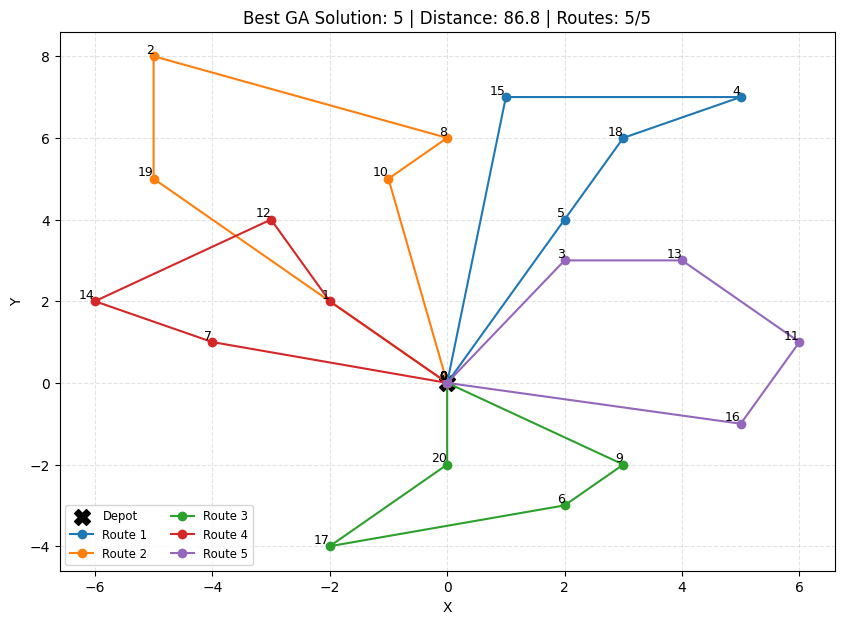

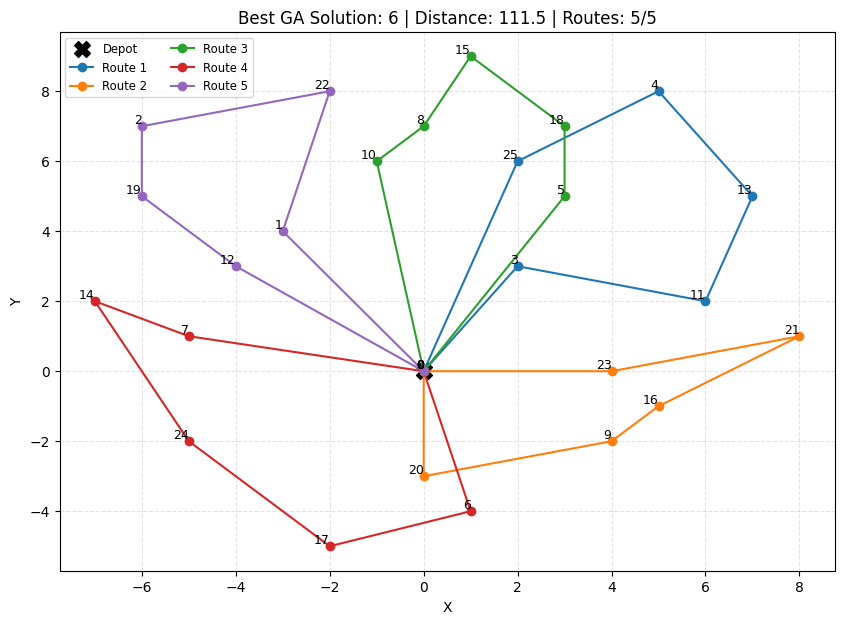

In [ ]:
# ==================== VISUALIZE BEST SOLUTIONS ====================
# Display best route configurations found for first 3 instances
# (to avoid cluttering with too many plots)

print("Generating visualizations for first 3 instances...\n")

for idx in range(min(3, len(all_instances))):
    instance = all_instances[idx]
    best_result = all_best_results[idx]
    summary_result = results_summary[idx]
    
    # Create informative title showing instance name, best distance, and resource usage
    title = (f"Best GA Solution: {instance['instance_id']} | "
             f"Distance: {summary_result['best']:.1f} | "
             f"Routes: {len(best_result['routes'])}/{instance['Nv']}")
    
    plot_routes(best_result["routes"], instance["customers"], title=title)

## 7. Performance Charts & Insights

Generate comparative charts showing solution quality across instances, including convergence behavior and solution consistency metrics.

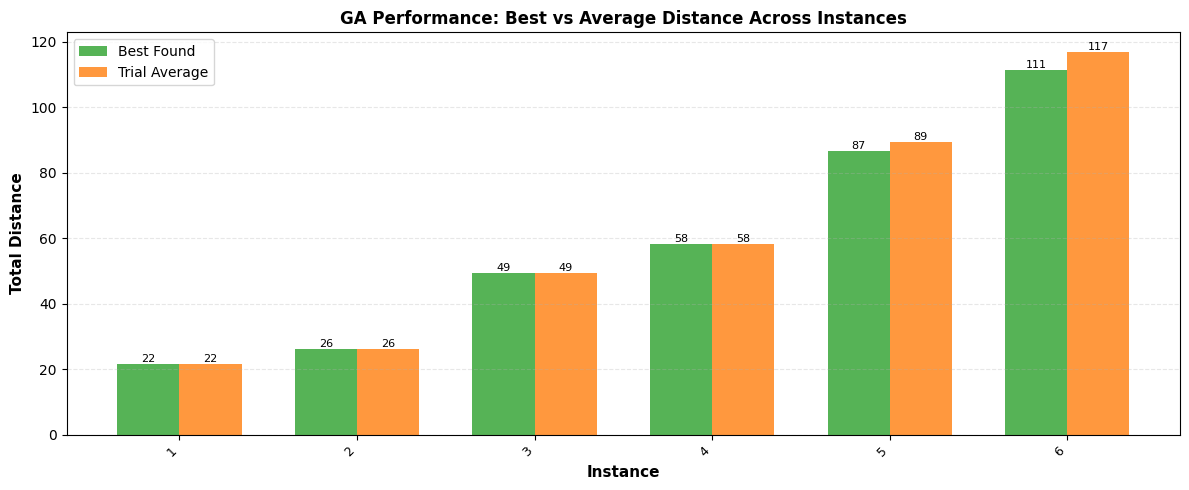

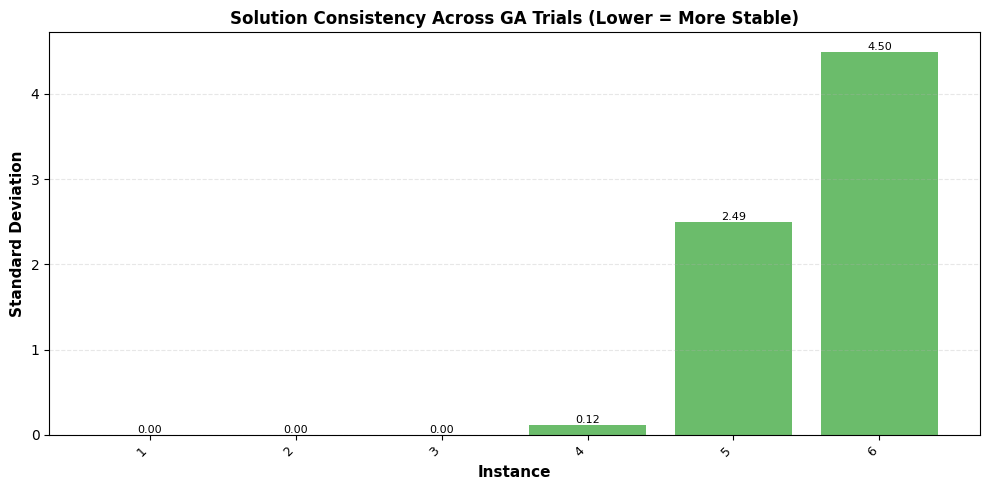

✓ Analysis complete! All instances processed.


In [ ]:
# ==================== PERFORMANCE ANALYSIS CHARTS ====================

# CHART 1: Best vs Average Distance Comparison
# Shows how consistent the GA is - smaller gap = more stable algorithm
print("Generating performance comparison charts...\n")

fig, ax = plt.subplots(figsize=(12, 5))
instance_names = [r["instance_id"][:15] for r in results_summary]  # Shorten names for display
best_distances = [r["best"] for r in results_summary]
avg_distances = [r["average"] for r in results_summary]

x = np.arange(len(instance_names))
width = 0.35  # Width of bars

# Create side-by-side bars
bars1 = ax.bar(x - width/2, best_distances, width, label="Best Found", color="tab:green", alpha=0.8)
bars2 = ax.bar(x + width/2, avg_distances, width, label="Trial Average", color="tab:orange", alpha=0.8)

ax.set_xlabel("Instance", fontsize=11, fontweight="bold")
ax.set_ylabel("Total Distance", fontsize=11, fontweight="bold")
ax.set_title("GA Performance: Best vs Average Distance Across Instances", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(instance_names, rotation=45, ha="right", fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3, axis="y")

# Add value labels on bars for precise reading
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f"{height:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# CHART 2: Solution Consistency by Instance
# Measures variability across trials - lower std dev = more robust algorithm
fig, ax = plt.subplots(figsize=(10, 5))
std_devs = [r["std_dev"] for r in results_summary]
# Color feasible solutions green, infeasible red
colors = ["tab:green" if r["valid"] else "tab:red" for r in results_summary]

bars = ax.bar(range(len(instance_names)), std_devs, color=colors, alpha=0.7)
ax.set_xlabel("Instance", fontsize=11, fontweight="bold")
ax.set_ylabel("Standard Deviation", fontsize=11, fontweight="bold")
ax.set_title("Solution Consistency Across GA Trials (Lower = More Stable)", fontsize=12, fontweight="bold")
ax.set_xticks(range(len(instance_names)))
ax.set_xticklabels(instance_names, rotation=45, ha="right", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3, axis="y")

# Label each bar with its value
for bar, std in zip(bars, std_devs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{std:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Analysis complete! All instances processed.")